In [1]:
import glob
import logging
from datetime import date

import matplotlib.pyplot as plt
import pandas as pd

from mlb_edge_finder import config
from mlb_edge_finder.backtest import compute_summary, run_backtest
from mlb_edge_finder.model import load_model
from mlb_edge_finder.training_data import load_training_set

config.setup_logging()

In [2]:
model_files = sorted(glob.glob(str(config.MODELS_DIR / "xgb_*.pkl")))
if not model_files:
    raise FileNotFoundError("No saved model found. Run training cells in 01_exploration.ipynb first.")

latest_model_path = model_files[-1]
model_date_str = latest_model_path.split("xgb_")[-1].replace(".pkl", "")
model_date = date.fromisoformat(model_date_str)

print(f"Loading model: {latest_model_path}")
clf = load_model(model_date)

SEASONS = [2019, 2021, 2022, 2023, 2024, 2025]
training_df = load_training_set(SEASONS)
print(f"Training data: {len(training_df):,} games across {SEASONS}")

Loading model: /Users/jaydengould/Documents/projects/mlb-edge-finder/models/xgb_2026-05-12.pkl
Training data: 15,050 games across [2019, 2021, 2022, 2023, 2024, 2025]


In [3]:
# Synthetic market odds: -110/-110 (50/50 market, 4.76% vig)
# Tests whether model outperforms naive even-money pricing.
# Real bookmaker lines vary — this is a lower bound on real-world profitability.
backtest_df = run_backtest(clf, training_df, home_market_prob=0.5, vig=0.0476, unit=100)
print(f"Bets placed: {len(backtest_df)}")
backtest_df.head(10)

2026-05-20 17:47:55,128 | INFO | mlb_edge_finder.backtest | Backtest complete: 2370 bets placed across 3010 test games


Bets placed: 2370


,game_date,home_name,away_name,bet_side,american_odds,model_prob,ev,kelly_fraction,actual_home_win,won,pnl,cumulative_pnl
0,2019-03-28,Texas Rangers,Chicago Cubs,home,-110,0.7205,0.3755,0.2065,0,False,-100.000000,-100.000000
1,2019-03-28,Toronto Blue Jays,Detroit Tigers,home,-110,0.8731,0.6667,0.3667,0,False,-100.000000,-200.000000
2,2019-03-29,Oakland Athletics,Los Angeles Angels,home,-110,0.5539,0.0575,0.0316,0,False,-100.000000,-300.000000
3,2019-03-30,Texas Rangers,Chicago Cubs,away,-110,0.6132,0.1707,0.0939,1,False,-100.000000,-400.000000
4,2019-03-30,Kansas City Royals,Chicago White Sox,away,-110,0.8373,0.5985,0.3292,1,False,-100.000000,-500.000000
5,2019-03-31,Toronto Blue Jays,Detroit Tigers,away,-110,0.6764,0.2912,0.1602,0,True,90.912562,-409.087438
6,2019-03-31,Philadelphia Phillies,Atlanta Braves,home,-110,0.7378,0.4085,0.2247,1,True,90.912562,-318.174876
7,2019-04-03,Kansas City Royals,Minnesota Twins,away,-110,0.7906,0.5093,0.2801,0,True,90.912562,-227.262314
8,2019-04-03,Atlanta Braves,Chicago Cubs,home,-110,0.8438,0.6109,0.3360,1,True,90.912562,-136.349752
9,2019-04-04,Oakland Athletics,Boston Red Sox,home,-110,0.7293,0.3923,0.2157,1,True,90.912562,-45.437190


In [4]:
summary = compute_summary(backtest_df, unit=100.0)

print("=" * 40)
print("BACKTEST SUMMARY")
print("=" * 40)
print(f"  Bets placed  : {summary['n_bets']}")
print(f"  Wins         : {summary['n_wins']}")
print(f"  Win rate     : {summary['win_rate']:.1%}")
print(f"  Total P&L    : ${summary['total_pnl']:+,.2f}")
print(f"  ROI          : {summary['roi_pct']:+.2f}%")
print(f"  Avg EV       : {summary['avg_ev']:.2%}")
print(f"  Max drawdown : ${summary['max_drawdown']:,.2f}")
print(f"  Sharpe ratio : {summary['sharpe_ratio']:.3f} (per-bet, not annualised)")
print("=" * 40)
print()
print("Assumptions:")
print("  - Market odds: -110 / -110 (50/50 even market, 4.76% vig)")
print("  - Bet size: $100 flat per flagged edge")
print("  - Test set: held-out 20% (stratified random split, same as model evaluation)")
print("  - Lookahead note: end-of-season team stats used for all games in each season")

BACKTEST SUMMARY
  Bets placed  : 2370
  Wins         : 1429
  Win rate     : 60.3%
  Total P&L    : $+35,814.05
  ROI          : +15.11%
  Avg EV       : 30.58%
  Max drawdown : $2,672.47
  Sharpe ratio : 0.162 (per-bet, not annualised)

Assumptions:
  - Market odds: -110 / -110 (50/50 even market, 4.76% vig)
  - Bet size: $100 flat per flagged edge
  - Test set: held-out 20% (stratified random split, same as model evaluation)
  - Lookahead note: end-of-season team stats used for all games in each season


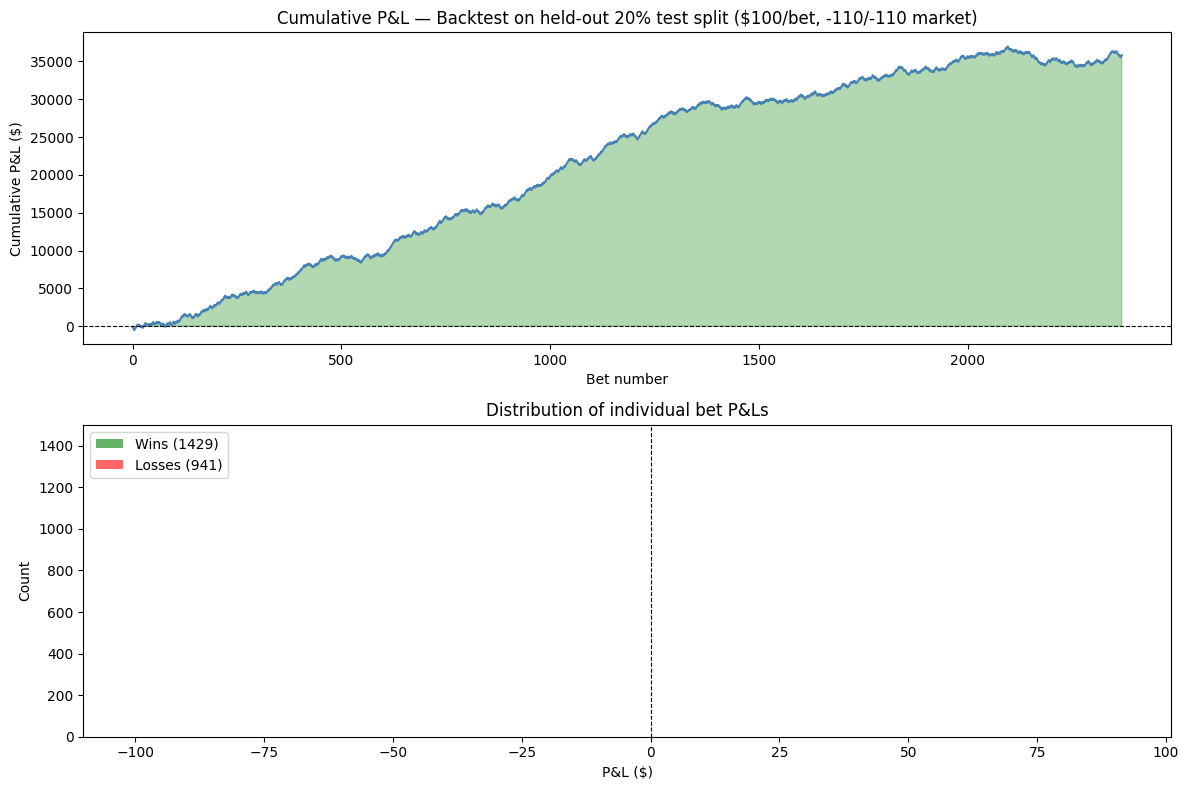

Plot saved to /Users/jaydengould/Documents/projects/mlb-edge-finder/notebooks/backtest_pnl.png


In [5]:
if backtest_df.empty:
    print("No bets found — model did not outperform the even-money market at the 5% EV threshold.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    axes[0].plot(backtest_df.index, backtest_df["cumulative_pnl"], color="steelblue", linewidth=1.5)
    axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].fill_between(
        backtest_df.index, backtest_df["cumulative_pnl"], 0,
        where=backtest_df["cumulative_pnl"] >= 0, alpha=0.3, color="green",
    )
    axes[0].fill_between(
        backtest_df.index, backtest_df["cumulative_pnl"], 0,
        where=backtest_df["cumulative_pnl"] < 0, alpha=0.3, color="red",
    )
    axes[0].set_title("Cumulative P&L — Backtest on held-out 20% test split ($100/bet, -110/-110 market)")
    axes[0].set_xlabel("Bet number")
    axes[0].set_ylabel("Cumulative P&L ($)")

    wins = backtest_df[backtest_df["won"]]["pnl"]
    losses = backtest_df[~backtest_df["won"]]["pnl"]
    axes[1].hist(wins, bins=20, color="green", alpha=0.6, label=f"Wins ({len(wins)})")
    axes[1].hist(losses, bins=20, color="red", alpha=0.6, label=f"Losses ({len(losses)})")
    axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("Distribution of individual bet P&Ls")
    axes[1].set_xlabel("P&L ($)")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    plt.tight_layout()
    _plot_path = config.MODELS_DIR.parent / "notebooks" / "backtest_pnl.png"
    plt.savefig(_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to {_plot_path}")